# Test of DAQ with Ophyd-Async ONLY

## Imports

### Global Imports

In [1]:
import numpy as np

from bluesky import RunEngine
from bluesky.callbacks import LiveTable
from bluesky.plans import count, list_scan
import bluesky.plan_stubs as bps

from bluesky.callbacks.tiled_writer import TiledWriter
from tiled.server import SimpleTiledServer
from tiled.client import from_uri

from ophyd_async.core import init_devices

import matplotlib.pyplot as plt

### Local-File Imports

In [2]:
from sidekick_model3_CA_devices_v4 import PulseGenerator, LilLaser, Diode # since v3 had synchrony issue
from sidekick_model3_PVA_devices_v4 import DiodePVA
from array_steps import array_one_nd_step_with_reps
from sidekick_model3_helpers import condition_pulse

## Initialize our Sidekick Model 3 Devices

#### Start Bluesky RunEngine (before initializing ophyd-async devices)

In [3]:
RE = RunEngine()

#### Initialize ophyd-async devices

In [4]:
with init_devices():
    pulsegen = PulseGenerator("PULSEGEN:", name="pulsegen")
    laser = LilLaser("LASER:", name="laser")
    electron = Diode("ELECTRON:", name="electron")
    proton = Diode("PROTON:", name="proton")
    electron_pva = DiodePVA(prefix="pva://ELECTRON-DAQ:", name="electron_pva")
    proton_pva = DiodePVA(prefix="pva://PROTON-DAQ:", name="proton_pva")

## Initialize our Tiled Server (local, temporary) and Subscribe to Run Engine

In [5]:
tiled_server = SimpleTiledServer()
tiled_client = from_uri(tiled_server.uri)

tw = TiledWriter(tiled_client)
RE.subscribe(tw)

Tiled version 0.2.12


0

## Create Plan to Put Sidekick in a Known Initial State

Set timing settings and rep-rate.

In [6]:
# Written by ChatGPT with help from Scott Feister on 2026-06-22.
# Simple Bluesky pre-run setup helper for putting Sidekick devices
# into a known initial state before opening a run.

def prepare_for_run():
    """Put the Sidekick Model 3 into the standard initial state before a run.
    """

    # Set all delta-t values.
    yield from bps.mv(
        proton.dt, 5.0e-6,        # seconds
        electron.dt, 5.0e-6,      # seconds
        laser.powers_dt, 5.0,     # microseconds
    )

    # Set trigger delays to known values.
    yield from bps.mv(
        pulsegen.ch2_delay, 100.0,    # microseconds; proton delay
        pulsegen.ch3_delay, 100.0,    # microseconds; electron delay
        pulsegen.ch4_delay, 100.0,    # microseconds; laser delay
    )

    # Set system repetition rate.
    yield from bps.mv(
        pulsegen.reprate, 50.0,       # Hz
    )

### Execute this Plan

In [7]:
RE(prepare_for_run())

()

## Explore: Create plan to Set Laser Powers and Return Traces

In [8]:
def one_pulse(pulse, md=None):
    # Data validity checks
    assert(isinstance(pulse, np.ndarray))
    assert(np.ndim(pulse) == 1)
    assert(len(pulse) == 100)
    assert(np.max(pulse) <= 255)
    assert(np.min(pulse) >= 0)
    if (np.count_nonzero(pulse - pulse.round() > 0)):
        raise Exception("Pulse array contains fractional values (should be only integers, from 0 to 255).")

    # Data type conversion to uint8
    pulse_uint8 = np.uint8(pulse)

    
    yield from bps.open_run(md=md)
    
    yield from bps.mv(
        laser.powers, pulse_uint8,
    )

    reading = yield from bps.trigger_and_read([
        laser.powers,
        electron_pva.trace,
        proton_pva.trace,
    ])

    yield from bps.close_run()

    return reading

In [9]:
pulse_descent = np.round(np.linspace(1, 0, 100)*255)
pulse_ascent = np.round(np.linspace(0, 1, 100)*255)
pulse_zero = np.round(np.ones(100)*0)
#pulse_spiky = np.uint8(np.tile([0,0,0,0,0,0,0,0,0,0,255,255,255,255,255,255,255,255,255,255], 5))
pulse_flat = np.round(np.ones(100)*255)
uid, = RE(one_pulse(pulse_descent))

In [10]:
list(tiled_client[uid, 'primary'])

['seq_num',
 'time',
 'laser-powers-readback',
 'electron_pva-trace-array',
 'electron_pva-trace-uniqueId',
 'electron_pva-trace-timeStamp',
 'proton_pva-trace-array',
 'proton_pva-trace-uniqueId',
 'proton_pva-trace-timeStamp',
 'ts_laser-powers-readback',
 'ts_electron_pva-trace-array',
 'ts_electron_pva-trace-uniqueId',
 'ts_electron_pva-trace-timeStamp',
 'ts_proton_pva-trace-array',
 'ts_proton_pva-trace-uniqueId',
 'ts_proton_pva-trace-timeStamp']

In [11]:
tiled_client[uid, 'primary']['electron_pva-trace-array'].read()

array([[  2,   0,   0,   0,   0,   0,   0,  22, 110, 197, 216, 214, 214,
        218, 213, 203, 203, 201, 193, 187, 187, 182, 176, 179, 180, 168,
        164, 166, 163, 155, 156, 157, 146, 142, 143, 140, 129, 128, 128,
        117, 117, 117, 114, 104, 102, 102,  95,  93,  94,  89,  81,  79,
         80,  73,  72,  72,  68,  62,  64,  64,  52,  48,  46,  45,  40,
         39,  38,  34,  32,  30,  23,  24,  23,  22,  18,  14,  15,  10,
         13,  13,  13,  10,   9,   8,   8,   6,   6,   5,   5,   4,   4,
          3,   3,   2,   2,   2,   1,   2,   2,   1]], dtype=uint16)

In [12]:
tiled_client[uid, 'primary']['laser-powers-readback'].read()

array([[255, 252, 250, 247, 245, 242, 240, 237, 234, 232, 229, 227, 224,
        222, 219, 216, 214, 211, 209, 206, 203, 201, 198, 196, 193, 191,
        188, 185, 183, 180, 178, 175, 173, 170, 167, 165, 162, 160, 157,
        155, 152, 149, 147, 144, 142, 139, 137, 134, 131, 129, 126, 124,
        121, 118, 116, 113, 111, 108, 106, 103, 100,  98,  95,  93,  90,
         88,  85,  82,  80,  77,  75,  72,  70,  67,  64,  62,  59,  57,
         54,  52,  49,  46,  44,  41,  39,  36,  33,  31,  28,  26,  23,
         21,  18,  15,  13,  10,   8,   5,   3,   0]], dtype=int32)

In [17]:
pulsegen.reprate.set(.5)

<AsyncStatus, device: pulsegen-reprate, task: <coroutine object AsyncStatusBase.__init__.<locals>.wait_with_error_message at 0x0000018ECB81FB40>, pending>

[13813307] [13813308]


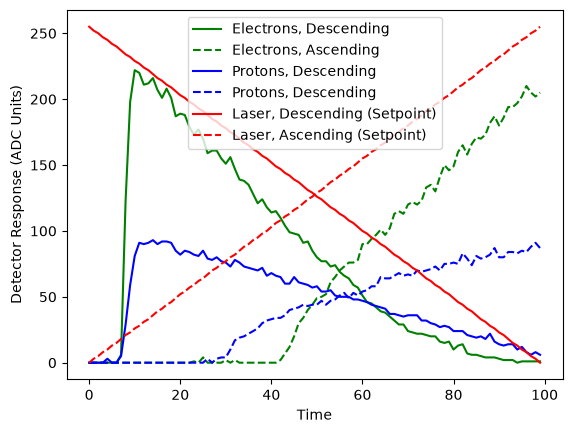

In [18]:
pulse_descent = np.round(np.linspace(1, 0, 100)*255)
pulse_ascent = np.round(np.linspace(0, 1, 100)*255)
#pulse_spiky = np.uint8(np.tile([0,0,0,0,0,0,0,0,0,0,255,255,255,255,255,255,255,255,255,255], 5))

uid_descent, = RE(one_pulse(pulse_descent))
uid_ascent, = RE(one_pulse(pulse_ascent))

def get_traces(uid, tiled_client=tiled_client):
    """ Extract relevant traces from a single-pulse run, identified by uid """
    elecs = tiled_client[uid, 'primary']['electron_pva-trace-array'].read().flatten()
    prots = tiled_client[uid, 'primary']['proton_pva-trace-array'].read().flatten()
    pulse = tiled_client[uid, 'primary']['laser-powers-readback'].read().flatten()
    return elecs, prots, pulse

print(tiled_client[uid_descent, 'primary']['electron_pva-trace-uniqueId'].read(), tiled_client[uid_ascent, 'primary']['electron_pva-trace-uniqueId'].read())

elecs1, prots1, pulse1 = get_traces(uid_descent)
elecs2, prots2, pulse2 = get_traces(uid_ascent)
#elecs3, prots3, pulse3 = realpulse(pulse_spiky)

plt.plot(elecs1, label="Electrons, Descending", c='g')
plt.plot(elecs2, '--', label="Electrons, Ascending", c='g')
#plt.plot(elecs3, '-.', label="Electrons, Spiky", c='g')
plt.plot(prots1, label="Protons, Descending", c='b')
plt.plot(prots2, '--', label="Protons, Descending", c='b')
#plt.plot(prots3, '-.', label="Protons, Spiky", c='b')
plt.plot(pulse1, label="Laser, Descending (Setpoint)", c='r')
plt.plot(pulse2, '--', label="Laser, Ascending (Setpoint)", c='r')
#plt.plot(pulse3, '-.', label="Laser, Spiky (Setpoint)", c='r')
plt.ylabel("Detector Response (ADC Units)")
plt.xlabel("Time")
plt.legend()

## Explore: How would we take multiple datapoints

In [15]:
uid, = RE(count([electron_pva.trace, proton_pva.trace], num=20))

In [16]:
list(tiled_client[uid, 'primary'])

['seq_num',
 'time',
 'electron_pva-trace-array',
 'electron_pva-trace-uniqueId',
 'electron_pva-trace-timeStamp',
 'proton_pva-trace-array',
 'proton_pva-trace-uniqueId',
 'proton_pva-trace-timeStamp',
 'ts_electron_pva-trace-array',
 'ts_electron_pva-trace-uniqueId',
 'ts_electron_pva-trace-timeStamp',
 'ts_proton_pva-trace-array',
 'ts_proton_pva-trace-uniqueId',
 'ts_proton_pva-trace-timeStamp']

In [17]:
tiled_client[uid, 'primary']['electron_pva-trace-uniqueId'].read()

array([13576671, 13576676, 13576677, 13576678, 13576679, 13576681,
       13576682, 13576683, 13576684, 13576685, 13576693, 13576694,
       13576696, 13576696, 13576698, 13576698, 13576699, 13576701,
       13576701, 13576702])

In [18]:
tiled_client[uid, 'primary']['proton_pva-trace-uniqueId'].read()

array([13576673, 13576676, 13576676, 13576677, 13576679, 13576680,
       13576681, 13576682, 13576683, 13576691, 13576692, 13576693,
       13576695, 13576696, 13576697, 13576698, 13576699, 13576700,
       13576701, 13576702])

In [19]:
tiled_client[uid, 'primary']['electron_pva-trace-array'].read()[1]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   2,
         0,   1,   3,   6,  11,  20,  25,  32,  38,  42,  42,  48,  51,
        51,  54,  58,  61,  61,  72,  76,  79,  80,  85,  86,  88,  96,
       100, 102, 104, 106, 109, 112, 112, 116, 119, 124, 129, 134, 141,
       143, 146, 150, 152, 152, 156, 166, 164, 166, 173, 177, 172, 176,
       192, 189, 186, 195, 201, 195, 198, 210, 205], dtype=uint16)

## Explore: Create plan to Set Laser Powers and Return Traces (with Multiple Reps)

In [20]:
def one_pulse2(pulse, reps=1, md=None):
    # Data validity checks
    assert(isinstance(pulse, np.ndarray))
    assert(np.ndim(pulse) == 1)
    assert(len(pulse) == 100)
    assert(np.max(pulse) <= 255)
    assert(np.min(pulse) >= 0)
    if (np.count_nonzero(pulse - pulse.round() > 0)):
        raise Exception("Pulse array contains fractional values (should be only integers, from 0 to 255).")

    # Data type conversion to uint8
    pulse_uint8 = np.uint8(pulse)

    
    yield from bps.open_run(md=md)
    
    yield from bps.mv(
        laser.powers, pulse_uint8,
    )

    yield from bps.trigger_and_read([
        laser.powers,
    ], name="settings")

    for i in range(reps):
        yield from bps.trigger_and_read([
            electron_pva.trace,
            proton_pva.trace,
        ], name="primary")

    yield from bps.close_run()

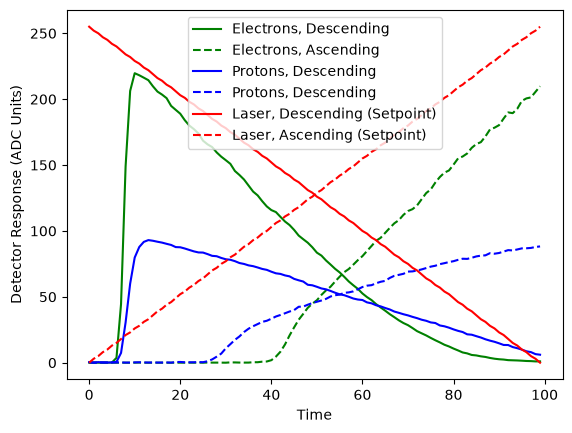

In [21]:
pulse_descent = np.round(np.linspace(1, 0, 100)*255)
pulse_ascent = np.round(np.linspace(0, 1, 100)*255)
#pulse_spiky = np.uint8(np.tile([0,0,0,0,0,0,0,0,0,0,255,255,255,255,255,255,255,255,255,255], 5))

reps = 50

uid_descent, = RE(one_pulse2(pulse_descent, reps=reps))
uid_ascent, = RE(one_pulse2(pulse_ascent, reps=reps))


def get_traces(uid, tiled_client=tiled_client):
    """ Extract relevant traces from a single-pulse run, identified by uid """
    elecs = tiled_client[uid, 'primary']['electron_pva-trace-array'].read().mean(axis=0)
    prots = tiled_client[uid, 'primary']['proton_pva-trace-array'].read().mean(axis=0)
    pulse = tiled_client[uid, 'settings']['laser-powers-readback'].read().flatten()
    return elecs, prots, pulse
    
elecs1, prots1, pulse1 = get_traces(uid_descent)
elecs2, prots2, pulse2 = get_traces(uid_ascent)
#elecs3, prots3, pulse3 = realpulse(pulse_spiky)

plt.plot(elecs1, label="Electrons, Descending", c='g')
plt.plot(elecs2, '--', label="Electrons, Ascending", c='g')
#plt.plot(elecs3, '-.', label="Electrons, Spiky", c='g')
plt.plot(prots1, label="Protons, Descending", c='b')
plt.plot(prots2, '--', label="Protons, Descending", c='b')
#plt.plot(prots3, '-.', label="Protons, Spiky", c='b')
plt.plot(pulse1, label="Laser, Descending (Setpoint)", c='r')
plt.plot(pulse2, '--', label="Laser, Ascending (Setpoint)", c='r')
#plt.plot(pulse3, '-.', label="Laser, Spiky (Setpoint)", c='r')
plt.ylabel("Detector Response (ADC Units)")
plt.xlabel("Time")
plt.legend()

## Next up: Try this as a ["List Scan"](https://nsls-ii.github.io/bluesky/generated/bluesky.plans.list_scan.html)